# Performance Evaluation Metrics

**Objective:** Evaluate and track intern performance through a metrics-based system.

**Steps:**
1. Upload your own performance data (or use the built-in sample data if you don't have a file yet)
2. Automatically calculate KPIs — task completion time, project quality, mentor feedback
3. Generate department summaries, trends, and flag interns needing attention
4. Download a complete, presentation-ready results package at the end






## 1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil

%matplotlib inline
pd.set_option("display.max_columns", None)


## 2. Upload your data (or skip to use sample data)

Run this cell. If you have a real dataset, click **"Choose Files"** when it appears and upload your CSV.
If you don't have a file yet, just click **Cancel/skip** — the notebook will automatically generate a sample dataset instead, so everything below still runs.


In [ ]:
uploaded_filename = None
try:
    from google.colab import files
    print("Upload your performance data CSV now, or close/cancel this dialog to use sample data instead.")
    uploaded = files.upload()
    if uploaded:
        uploaded_filename = list(uploaded.keys())[0]
        print(f"\nUploaded file: {uploaded_filename}")
except ImportError:
    print("Not running in Google Colab — skipping upload, will use sample data.")
except Exception as e:
    print("No file uploaded — will use sample data instead.")


Upload your performance data CSV now, or close/cancel this dialog to use sample data instead.


Saving intern_performance_test_data_500.csv to intern_performance_test_data_500 (1).csv

Uploaded file: intern_performance_test_data_500 (1).csv


## 3. Load data (uploaded file if provided, otherwise generate sample data)

In [ ]:
required_cols = ["Intern_ID","Name","Department","Month","Tasks_Assigned","Tasks_Completed_On_Time",
                 "Avg_Deadline_Days","Avg_Completion_Time_Days","Project_Quality_Score","Mentor_Feedback_Score"]

df = None
if uploaded_filename:
    try:
        temp = pd.read_csv(uploaded_filename)
        missing = [c for c in required_cols if c not in temp.columns]
        if missing:
            print(f"Uploaded file is missing expected columns: {missing}")
            print("Falling back to sample data instead. Rename your columns to match and re-run if you want to use your real file.")
        else:
            df = temp
            print(f"Using your uploaded data: {df.shape[0]} rows, {df.shape[1]} columns")
    except Exception as e:
        print("Could not read the uploaded file, falling back to sample data. Error:", e)

if df is None:
    print("Generating sample performance dataset (30 interns x 6 months)...")
    np.random.seed(21)
    first_names = ["Ali","Sara","Ahmed","Ayesha","Bilal","Hina","Usman","Zara","Hamza","Mahnoor",
                   "Omar","Fatima","Danish","Amna","Talha","Sana","Kashif","Iqra","Faisal","Nida",
                   "Zain","Mariam","Adeel","Sadia","Hassan","Noor","Waqas","Laiba","Rehan","Areeba"]
    last_names = ["Khan","Malik","Butt","Raza","Shaikh","Iqbal","Chaudhry","Aslam","Farooq","Javed"]
    departments = ["Web Development","Data Analysis","Graphic Design","Digital Marketing"]
    months = ["2026-02","2026-03","2026-04","2026-05","2026-06","2026-07"]

    interns = []
    for i in range(30):
        interns.append({
            "Intern_ID": 2001 + i,
            "Name": f"{np.random.choice(first_names)} {np.random.choice(last_names)}",
            "Department": np.random.choice(departments),
            "_base_quality": np.clip(np.random.normal(7, 1.3), 3, 10),
            "_base_reliability": np.clip(np.random.normal(0.78, 0.15), 0.3, 1.0),
        })

    rows = []
    for intern in interns:
        for month in months:
            tasks_assigned = np.random.randint(4, 9)
            on_time_prob = np.clip(intern["_base_reliability"] + np.random.normal(0, 0.08), 0.1, 1.0)
            tasks_on_time = np.random.binomial(tasks_assigned, on_time_prob)
            deadline_days = np.random.choice([3, 5, 7])
            avg_completion_days = round(np.clip(
                deadline_days * (1.6 - on_time_prob) + np.random.normal(0, 0.6), 1, deadline_days*2.5), 1)
            quality_score = round(np.clip(intern["_base_quality"] + np.random.normal(0, 0.6), 1, 10), 1)
            mentor_feedback_score = round(np.clip(
                0.6*quality_score + 0.4*(on_time_prob*10) + np.random.normal(0, 0.5), 1, 10), 1)
            rows.append({
                "Intern_ID": intern["Intern_ID"], "Name": intern["Name"], "Department": intern["Department"],
                "Month": month, "Tasks_Assigned": tasks_assigned, "Tasks_Completed_On_Time": tasks_on_time,
                "Avg_Deadline_Days": deadline_days, "Avg_Completion_Time_Days": avg_completion_days,
                "Project_Quality_Score": quality_score, "Mentor_Feedback_Score": mentor_feedback_score,
            })
    df = pd.DataFrame(rows)
    print(f"Sample dataset ready: {df.shape[0]} rows, {df.shape[1]} columns")

df.to_csv("intern_performance_metrics.csv", index=False)
df.head(10)


Using your uploaded data: 500 rows, 10 columns


,Intern_ID,Name,Department,Month,Tasks_Assigned,Tasks_Completed_On_Time,Avg_Deadline_Days,Avg_Completion_Time_Days,Project_Quality_Score,Mentor_Feedback_Score
0,4001,Sara Raza,Data Analysis,2026-02,7,6,7,5.5,7.6,9.1
1,4001,Sara Raza,Data Analysis,2026-03,6,6,3,2.1,8.8,9.1
2,4001,Sara Raza,Data Analysis,2026-04,5,5,7,5.3,8.0,8.5
3,4001,Sara Raza,Data Analysis,2026-05,7,6,5,2.1,7.9,8.2
4,4001,Sara Raza,Data Analysis,2026-06,4,4,5,3.8,9.1,10.0
5,4002,Bilal Iqbal,Web Development,2026-02,8,6,7,5.1,4.1,6.0
6,4002,Bilal Iqbal,Web Development,2026-03,6,6,4,2.5,4.6,5.4
7,4002,Bilal Iqbal,Web Development,2026-04,8,7,3,2.0,5.2,6.7
8,4002,Bilal Iqbal,Web Development,2026-05,4,2,4,3.7,5.6,7.0
9,4002,Bilal Iqbal,Web Development,2026-06,9,8,5,3.5,6.1,7.2


## 4. Design & Calculate KPIs

Three KPIs, as required by the task:
- **On-Time Completion Rate** — % of tasks finished by the deadline
- **Project Quality Score** — mentor-rated quality of submitted work (1-10)
- **Mentor Feedback Score** — mentor's overall feedback rating (1-10)

Combined into one weighted **Performance Score** for ranking.


In [ ]:
df["On_Time_Completion_Rate_Pct"] = (df["Tasks_Completed_On_Time"] / df["Tasks_Assigned"] * 100).round(1)

df["Performance_Score"] = (
    0.30 * df["On_Time_Completion_Rate_Pct"] / 10 +
    0.40 * df["Project_Quality_Score"] +
    0.30 * df["Mentor_Feedback_Score"]
).round(2)

df[["Intern_ID","Name","Month","On_Time_Completion_Rate_Pct",
    "Project_Quality_Score","Mentor_Feedback_Score","Performance_Score"]].head(8)


,Intern_ID,Name,Month,On_Time_Completion_Rate_Pct,Project_Quality_Score,Mentor_Feedback_Score,Performance_Score
0,4001,Sara Raza,2026-02,85.7,7.6,9.1,8.34
1,4001,Sara Raza,2026-03,100.0,8.8,9.1,9.25
2,4001,Sara Raza,2026-04,100.0,8.0,8.5,8.75
3,4001,Sara Raza,2026-05,85.7,7.9,8.2,8.19
4,4001,Sara Raza,2026-06,100.0,9.1,10.0,9.64
5,4002,Bilal Iqbal,2026-02,75.0,4.1,6.0,5.69
6,4002,Bilal Iqbal,2026-03,100.0,4.6,5.4,6.46
7,4002,Bilal Iqbal,2026-04,87.5,5.2,6.7,6.72


## 5. Automated Monthly Extraction

In [ ]:
latest_month = df["Month"].max()
monthly = df[df["Month"] == latest_month].copy()
monthly = monthly.sort_values("Performance_Score", ascending=False).reset_index(drop=True)
monthly["Rank"] = monthly.index + 1
monthly["Needs_Attention"] = np.where(
    (monthly["On_Time_Completion_Rate_Pct"] < 60) | (monthly["Performance_Score"] < 6.0),
    "YES", "NO"
)

print(f"Monthly report generated for: {latest_month}")
print(f"Interns evaluated: {len(monthly)}")
print(f"Interns flagged for attention: {(monthly['Needs_Attention']=='YES').sum()}")
monthly[["Rank","Name","Department","On_Time_Completion_Rate_Pct",
         "Project_Quality_Score","Mentor_Feedback_Score","Performance_Score","Needs_Attention"]].head(10)


Monthly report generated for: 2026-06
Interns evaluated: 100
Interns flagged for attention: 27


,Rank,Name,Department,On_Time_Completion_Rate_Pct,Project_Quality_Score,Mentor_Feedback_Score,Performance_Score,Needs_Attention
0,1,Ahmed Abbasi,Digital Marketing,100.0,10.0,10.0,10.00,NO
1,2,Faisal Qureshi,Digital Marketing,88.9,10.0,10.0,9.67,NO
2,3,Sara Raza,Data Analysis,100.0,9.1,10.0,9.64,NO
3,4,Bilal Gill,Digital Marketing,100.0,9.1,9.8,9.58,NO
4,5,Komal Farooq,Digital Marketing,100.0,8.9,9.4,9.38,NO
5,6,Wajiha Khan,Graphic Design,100.0,9.0,9.2,9.36,NO
6,7,Sana Iqbal,Web Development,100.0,9.0,9.0,9.30,NO
7,8,Zara Abbasi,Graphic Design,87.5,10.0,8.6,9.20,NO
8,9,Laiba Shaikh,Graphic Design,88.9,9.3,9.2,9.15,NO
9,10,Mariam Baig,Web Development,100.0,9.4,7.7,9.07,NO


## 6. Department Summary & Monthly Trend

In [ ]:
dept_summary = df[df["Month"]==latest_month].groupby("Department").agg(
    Avg_On_Time_Rate=("On_Time_Completion_Rate_Pct","mean"),
    Avg_Quality_Score=("Project_Quality_Score","mean"),
    Avg_Feedback_Score=("Mentor_Feedback_Score","mean"),
    Avg_Performance_Score=("Performance_Score","mean"),
    Intern_Count=("Intern_ID","count"),
).round(2).reset_index()

trend = df.groupby("Month").agg(
    Avg_On_Time_Rate=("On_Time_Completion_Rate_Pct","mean"),
    Avg_Quality_Score=("Project_Quality_Score","mean"),
    Avg_Feedback_Score=("Mentor_Feedback_Score","mean"),
    Avg_Performance_Score=("Performance_Score","mean"),
).round(2).reset_index()

print("Department summary:")
display(dept_summary)
print("\nMonthly trend:")
display(trend)


Department summary:


,Department,Avg_On_Time_Rate,Avg_Quality_Score,Avg_Feedback_Score,Avg_Performance_Score,Intern_Count
0,Data Analysis,74.22,7.40,7.42,7.41,26
1,Digital Marketing,79.79,7.22,7.52,7.54,27
2,Graphic Design,73.91,6.61,7.06,6.98,21
3,Web Development,75.72,6.59,6.72,6.92,26



Monthly trend:


,Month,Avg_On_Time_Rate,Avg_Quality_Score,Avg_Feedback_Score,Avg_Performance_Score
0,2026-02,73.81,7.07,7.36,7.25
1,2026-03,77.19,7.09,7.22,7.32
2,2026-04,76.86,6.98,7.34,7.30
3,2026-05,76.45,7.06,7.33,7.32
4,2026-06,76.05,6.98,7.19,7.23


## 7. Visualizations

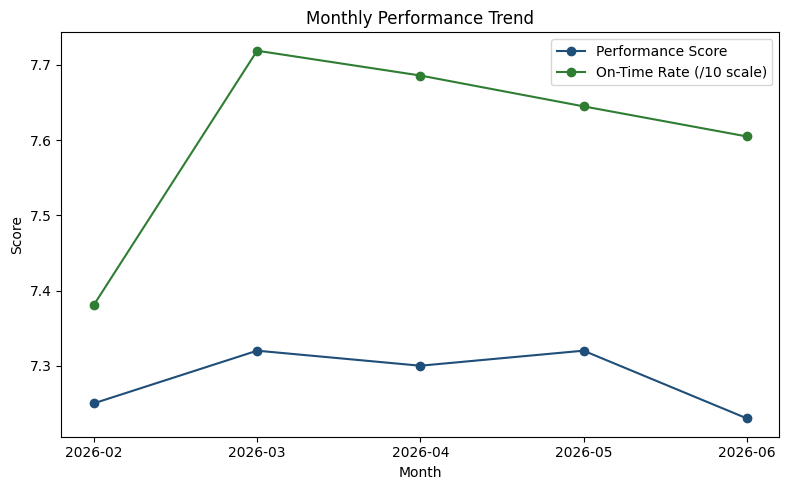

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(trend["Month"], trend["Avg_Performance_Score"], marker="o", color="#1F4E78", label="Performance Score")
plt.plot(trend["Month"], trend["Avg_On_Time_Rate"]/10, marker="o", color="#2E7D32", label="On-Time Rate (/10 scale)")
plt.title("Monthly Performance Trend")
plt.xlabel("Month"); plt.ylabel("Score"); plt.legend()
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=150)
plt.show()


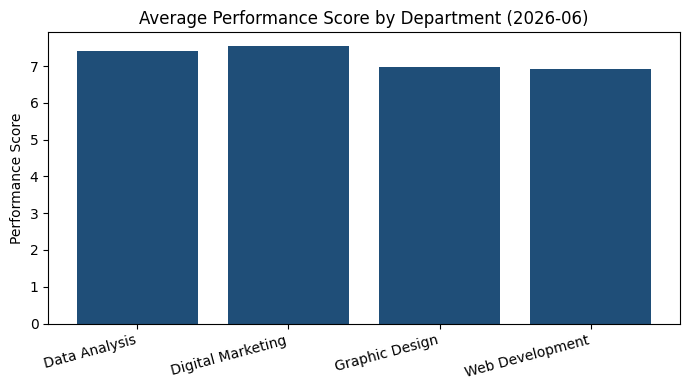

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(dept_summary["Department"], dept_summary["Avg_Performance_Score"], color="#1F4E78")
plt.title(f"Average Performance Score by Department ({latest_month})")
plt.ylabel("Performance Score")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("department_comparison.png", dpi=150)
plt.show()


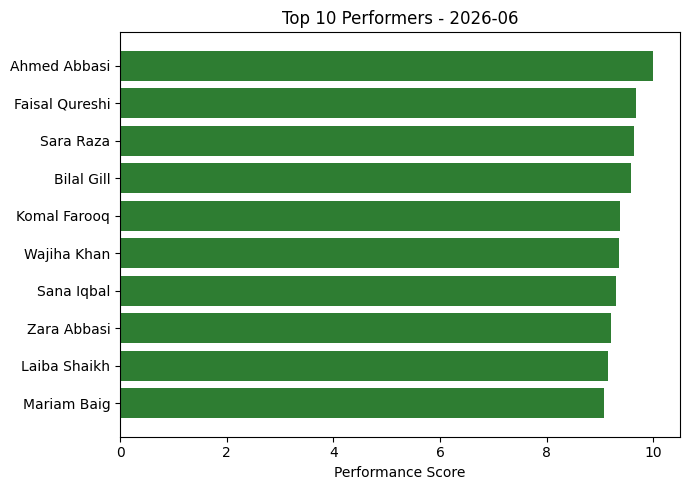

In [ ]:
top10 = monthly.head(10)
plt.figure(figsize=(7,5))
plt.barh(top10["Name"][::-1], top10["Performance_Score"][::-1], color="#2E7D32")
plt.title(f"Top 10 Performers - {latest_month}")
plt.xlabel("Performance Score")
plt.tight_layout()
plt.savefig("top_performers.png", dpi=150)
plt.show()


## 8. Key Insights for Supervisors

- KPIs are calculated automatically every time this notebook runs — no manual recalculation needed, whether using sample data or your own real file.
- The department with the highest average performance score stands out as a possible model for mentorship approach or workflow.
- Interns flagged **"Needs Attention"** (on-time rate below 60% or performance score below 6.0) are the clearest candidates for a direct mentor check-in.
- Monthly trend shows how completion rate, quality, and feedback move over time — useful for spotting whether a dip is temporary or a pattern.


## 9. Download Your Results

This packages everything — the monthly report, department summary, trend data, and all charts — into one folder and zips it up, ready to download and use in your submission or presentation.


In [ ]:
results_folder = "performance_report_results"
os.makedirs(results_folder, exist_ok=True)

monthly.to_csv(f"{results_folder}/monthly_report_{latest_month}.csv", index=False)
dept_summary.to_csv(f"{results_folder}/department_summary_{latest_month}.csv", index=False)
trend.to_csv(f"{results_folder}/monthly_trend_all_months.csv", index=False)

for chart in ["monthly_trend.png", "department_comparison.png", "top_performers.png"]:
    if os.path.exists(chart):
        shutil.copy(chart, results_folder)

zip_name = f"Performance_Evaluation_Results_{latest_month}"
shutil.make_archive(zip_name, "zip", results_folder)
print(f"Results packaged into: {zip_name}.zip")
print("Contents:")
for f in os.listdir(results_folder):
    print(" -", f)


Results packaged into: Performance_Evaluation_Results_2026-06.zip
Contents:
 - monthly_trend_all_months.csv
 - department_comparison.png
 - monthly_report_2026-06.csv
 - department_summary_2026-06.csv
 - top_performers.png
 - monthly_trend.png


In [ ]:
try:
    from google.colab import files
    files.download(f"{zip_name}.zip")
    print("Download starting...")
except ImportError:
    print(f"Not running in Colab — find your results in the '{results_folder}' folder")
    print(f"or the zipped file '{zip_name}.zip' in your working directory.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download starting...
